# Final Project

## Import Relevant Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ! pip install arch
# from arch import arch_model
from scipy.stats import norm, gaussian_kde, skew, kurtosis, mode
from scipy.ndimage import gaussian_filter1d

## Step 1: Simulate Market Returns with GARCH

In [2]:
# Set randomization seed (optional)
# np.random.seed(100)

# Step 1: Simulate Market Returns with GARCH (Manual Implementation)
n_periods = 252  # Number of time steps

# Initial parameters
S0 = 100  # Initial stock price
T = 1     # 1-year maturity
dt = T / n_periods  # Time step
r = 0.05  # Risk-free rate
K = 100  # Strike price
num_calls = 10  # Number of call options held
shares_per_call = 100 # Number of shares tied to a single contract

# Constant volatility
def do_const_vol(n_periods, vol):
  returns = np.random.normal(loc=0, scale=vol * np.sqrt(1 / n_periods), size=n_periods)
  volatility = np.full(n_periods, vol)
  return returns, volatility

# GARCH
def do_garch(n_periods):
  # GARCH(1,1) Parameters
  omega = 0.1  # Long-term volatility component
  alpha = 0.1  # Impact of previous squared return
  beta = 0.8  # Impact of previous variance

  # Initialize arrays
  returns = np.zeros(n_periods)
  volatility = np.zeros(n_periods)
  volatility[0] = np.sqrt(omega / (1 - alpha - beta))  # Long-run variance

  # Simulate GARCH(1,1) process
  for t in range(1, n_periods):
      returns[t] = volatility[t - 1] * np.random.normal()
      volatility[t] = np.maximum(np.sqrt(omega + alpha * returns[t - 1]**2 + beta * volatility[t - 1]**2), 1e-6)

  return returns, volatility

# def egarch(n_periods, returns):
#   lmbda = 0.05  # Leverage effect term
#   volatility = np.zeros(n_periods)
#   volatility[0] = volatility[0]

#   for t in range(1, n_periods):
#       log_vol = np.log(volatility[t - 1]**2)
#       shock = np.abs(returns[t - 1]) - np.sqrt(2 / np.pi)
#       log_vol = omega + alpha * shock + beta * log_vol + lmbda * returns[t - 1]
#       volatility[t] = np.exp(log_vol / 2)
#   return volatility

# Simulate a sudden jump in volatility, like a market crash
def do_garch_with_shock(n_periods, shock_time=None, shock_factor=2.0):
  omega = 0.1
  alpha = 0.1
  beta = 0.8

  returns = np.zeros(n_periods)
  volatility = np.zeros(n_periods)
  volatility[0] = np.sqrt(omega / (1 - alpha - beta))

  # Set a shock at a random time if not specified
  if shock_time is None:
      shock_time = np.random.randint(n_periods // 2, n_periods)

  for t in range(1, n_periods):
      if t == shock_time:
          volatility[t - 1] *= shock_factor  # Apply shock

      returns[t] = volatility[t - 1] * np.random.normal()
      volatility[t] = np.maximum(np.sqrt(omega + alpha * returns[t - 1]**2 + beta * volatility[t - 1]**2), 1e-6)

  return returns, volatility

## Step 2: Simulate Underlying Asset Prices

In [8]:
# We can switch between using GARCH or constant volatility regimes
use_garch = True  # Set to True to use GARCH, False for constant volatility
if use_garch:
  returns, volatility = do_garch(n_periods)
else:
  returns, volatility = do_const_vol(n_periods, 0.1)

In [9]:
def simulate_stock_prices(S0, returns):
    """
    Simulate stock prices using simulated returns.

    Parameters:
    S0 (float): Initial stock price.
    returns (array): Simulated returns.

    Returns:
    prices (array): Simulated stock prices.
    """
    prices = np.zeros(len(returns))
    prices[0] = S0  # Initial stock price

    # Compute stock prices
    for t in range(1, len(returns)):
        prices[t] = prices[t - 1] + returns[t]  # Logarithmic returns

    return prices

prices = simulate_stock_prices(100, returns)

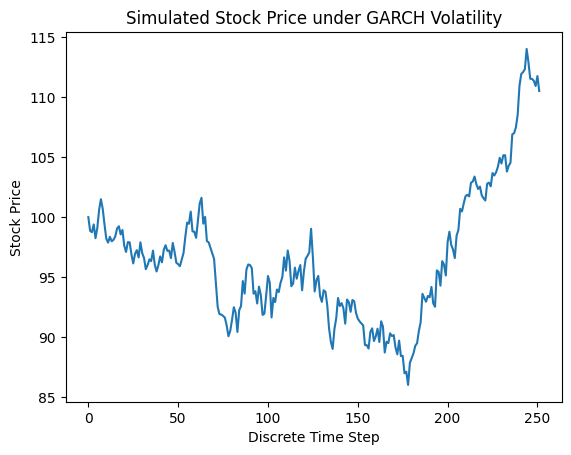

In [10]:
plt.plot(prices)
plt.xlabel('Discrete Time Step')
plt.ylabel('Stock Price')
plt.title('Simulated Stock Price under GARCH Volatility')
plt.show()

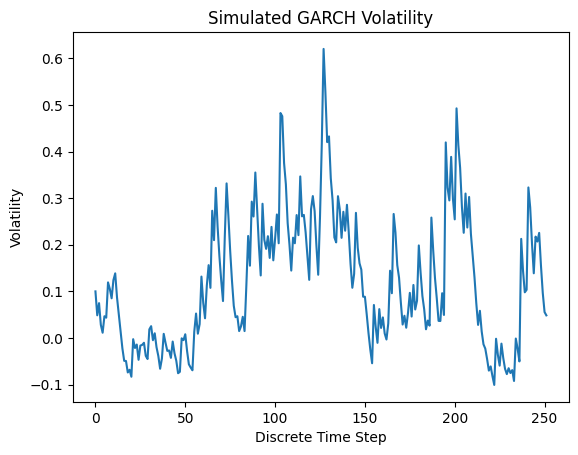

In [13]:
plt.plot(volatility)
plt.xlabel('Discrete Time Step')
plt.ylabel('Volatility')
plt.title('Simulated GARCH Volatility')
plt.show()

## Step 3: Compute European Call Option Prices (Black-Scholes Formula)

In [14]:
def black_scholes_call(S, K, T, r, sigma):
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T) + np.finfo(float).eps)
  d2 = d1 - sigma * np.sqrt(T)
  return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

## Step 4: Implement Delta Hedging

In [15]:
def compute_delta(S, K, T, r, sigma, option_type='call'):
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T) + np.finfo(float).eps)
  if option_type == 'call':
    return norm.cdf(d1)
  elif option_type == 'put':
    return norm.cdf(d1) - 1

## Step 5: Compare Frequent vs. Infrequent Rehedging

In [16]:
# I'm pretty confident this works. Delta hedging with a particular freq.
def run_simulation(frequency, times, S):
  hedge_positions = np.zeros(len(times))
  option_prices = np.zeros(len(times))
  portfolio_value = np.zeros(len(times))

  hedged_shares = 0   # Initially, no stock is shorted
  cash = 0            # No initial cash for simplicity
  deltas = []

  for t in range(n_periods):
    remaining_T = T - times[t]
    option_prices[t] = black_scholes_call(S[t], K, remaining_T, r, 0.1) * num_calls

    # Hedge based on the frequency
    if t % frequency == 0:
      delta = compute_delta(S[t], K, remaining_T, r, 0.1)
      deltas.append(delta)
      total_delta = delta * num_calls

      hedge_adjustement = total_delta - hedged_shares
      hedged_shares = total_delta
      prev_cash = cash
      cash += ((0 if t == 0 else -hedge_positions[t-1]) + hedged_shares) * S[t]


    hedge_positions[t] = hedged_shares
    portfolio_value[t] = -(hedged_shares * S[t]) + option_prices[t] + cash
    # portfolio_value[t] = delta

  if(frequency == 1):
    plt.plot(deltas)
    plt.xlabel('Discrete Time Steps')
    plt.ylabel('Delta')
    plt.title('Delta Over Time, under GARCH Volatility')
    plt.show()
  print(option_prices[0])
  print(hedge_positions[0])
  return hedge_positions, option_prices, portfolio_value, cash

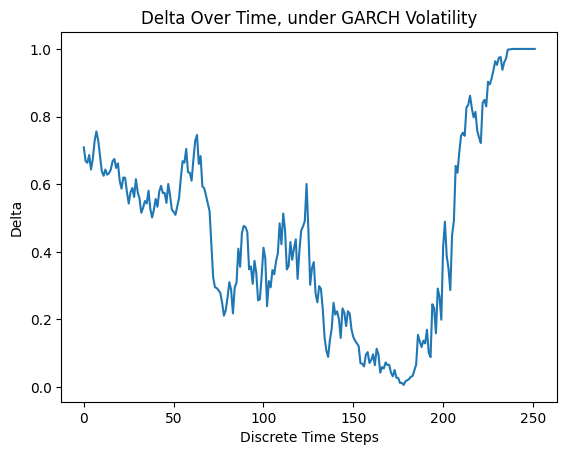

68.04957708822158
7.088403132116532
68.04957708822158
7.088403132116532
68.04957708822158
7.088403132116532
68.04957708822158
7.088403132116532


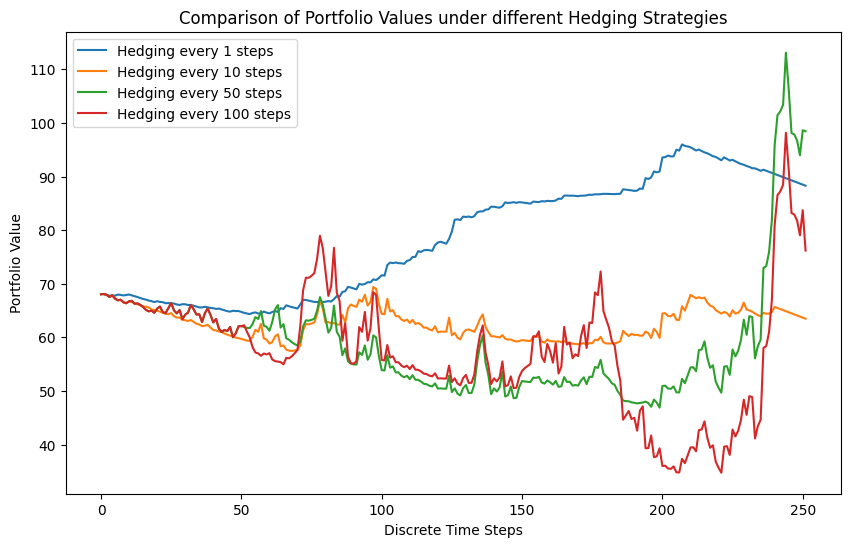

Hedging every 1 steps: Final P&L = 20.25
Hedging every 10 steps: Final P&L = -4.57
Hedging every 50 steps: Final P&L = 30.40
Hedging every 100 steps: Final P&L = 8.14


In [19]:
# Delta Hedging approach
hedge_freq = [1, 10, 50, 100]
hedge_results = {}
pnl_results = {}

for freq in hedge_freq:
  hedge_positions, option_prices, portfolio_values, cash = run_simulation(freq, np.linspace(0, T, n_periods), prices)
  hedge_results[f'Hedging every {freq} steps'] = portfolio_values
  pnl_results[f'Hedging every {freq} steps'] = portfolio_values[-1] - portfolio_values[0]
  # pnl_results[f'Hedging every {freq} steps'] = cash

# Step 6: Plot Results
plt.figure(figsize=(10, 6))
for freq in hedge_freq:
    plt.plot(hedge_results[f'Hedging every {freq} steps'], label=f'Hedging every {freq} steps')
plt.legend()
plt.title('Comparison of Portfolio Values under different Hedging Strategies')
plt.xlabel('Discrete Time Steps')
plt.ylabel('Portfolio Value')
plt.show()

# Print P&L for each strategy
for strategy, pnl in pnl_results.items():
    print(f'{strategy}: Final P&L = {pnl:.2f}')


In [ ]:
print(portfolio_values[0])

-68.04957708822155


 # Using Historical Data

In [ ]:
import pandas as pd

df = pd.read_csv('/content/fvu8du0mig0fsxjy.csv')
df['strike_price'] = df['strike_price'] / 1000
df = df[df.strike_price == 1850]
df = df[df.exdate == '2023-01-31']
display(df.head())

,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,forward_price,index_flag,issuer,exercise_style
3219,2022-11-10,2023-01-31,C,1850.0,109.5,113.1,0,2,0.274060,0.573488,0.001612,346.3202,-237.4409,148731707,NaN,1,RUSSELL 2000 INDEX,E
7167,2022-11-11,2023-01-31,C,1850.0,115.5,118.7,1,2,0.270231,0.594913,0.001611,342.4518,-231.7949,148731707,NaN,1,RUSSELL 2000 INDEX,E
10881,2022-11-14,2023-01-31,C,1850.0,103.6,106.3,0,2,0.269294,0.568274,0.001696,338.0759,-246.9900,148731707,NaN,1,RUSSELL 2000 INDEX,E
14431,2022-11-15,2023-01-31,C,1850.0,118.0,120.7,0,2,0.270721,0.608327,0.001631,332.3532,-240.8564,148731707,NaN,1,RUSSELL 2000 INDEX,E
17981,2022-11-16,2023-01-31,C,1850.0,95.2,97.8,0,2,0.264333,0.550679,0.001768,334.1275,-240.7571,148731707,NaN,1,RUSSELL 2000 INDEX,E


Data Starting Nov 1, 2022. 1867.93 is where we get Nov 10 price

In [ ]:
historical_data = pd.Series([1851.39, 1789.14, 1779.73, 1799.87, 1809.81, 1808.93, 1760.4, 1867.93, 1882.74, 1861.25, 1889.2, 1853.17, 1839.12, 1849.73, 1839.14, 1860.44, 1863.52, 1869.19, 1830.96, 1836.55, 1886.58, 1881.68, 1892.84, 1840.22, 1812.58, 1806.9, 1818.29, 1796.66, 1818.61, 1832.36, 1820.45, 1774.61, 1763.42, 1738.58, 1748.02, 1776.94, 1754.09, 1760.93, 1749.52, 1722.02, 1766.25, 1761.25, 1750.72, 1772.54, 1753.19, 1792.8, 1795.91, 1822.65, 1844.05, 1876.06, 1887.03, 1884.29, 1854.36, 1836.35, 1867.34, 1890.77, 1885.61, 1890.32, 1903.06, 1911.46, 1885.72, 1931.94, 1960.81, 2001.22, 1985.53, 1957.72, 1972.61, 1942.6, 1915.34, 1918.81, 1941.14, 1939.91, 1960.97, 1942.21, 1946.36, 1888.21, 1894.68, 1908.09, 1890.49, 1896.27, 1896.99])

In [ ]:
print(len(historical_data))
print(len(df))

81
55


In [ ]:
def calculate_realized_volatility(prices, window=10):
    """
    Calculate the historical (realized) volatility using log returns.

    :param prices: List or Series of stock prices
    :param window: Number of days for rolling volatility (default: 30)
    :return: Realized volatility (annualized)
    """
    # Compute log returns
    log_returns = np.log(prices / prices.shift(1))

    # Compute rolling standard deviation of returns
    rolling_volatility = log_returns.rolling(window=window).std()

    # Annualize the volatility
    annualized_volatility = rolling_volatility * np.sqrt(252)

    return annualized_volatility

# Example: Simulated Stock Prices
# stock_prices = pd.Series([100, 102, 101, 105, 110, 108, 112, 115, 118, 120])

# Compute 30-day rolling volatility
realized_vol = calculate_realized_volatility(historical_data, window=7).dropna()
print(len(realized_vol))
print(realized_vol)  # Drop NaN values for first 10 days

74
7     0.484899
8     0.416521
9     0.425939
10    0.428245
11    0.456517
        ...   
76    0.229738
77    0.220085
78    0.223162
79    0.206246
80    0.205150
Length: 74, dtype: float64


In [ ]:
historical_data[7:62]

,0
7,1867.93
8,1882.74
9,1861.25
10,1889.20
11,1853.17
12,1839.12
13,1849.73
14,1839.14
15,1860.44
16,1863.52


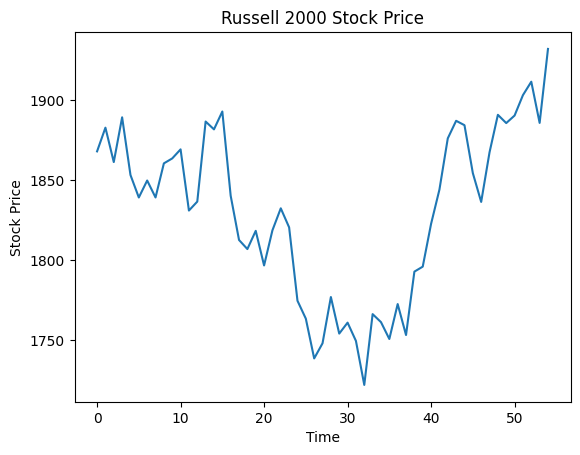

In [ ]:
historical_data = historical_data[7:62]
historical_data = historical_data.reset_index(drop=True)
plt.plot(historical_data)
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Russell 2000 Stock Price')
plt.show()

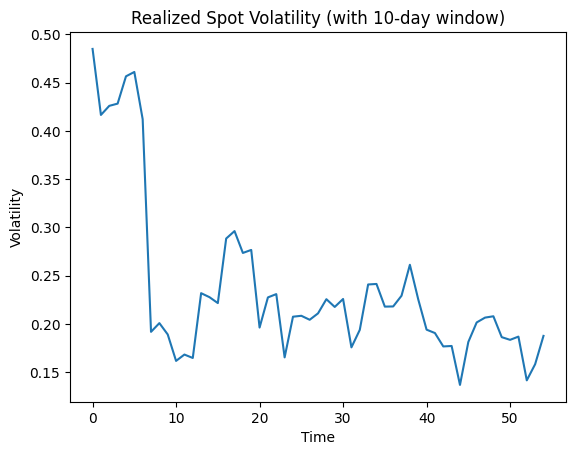

In [ ]:
realized_vol = realized_vol[:55]
realized_vol = realized_vol.reset_index(drop=True)
plt.plot(realized_vol)
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.title('Realized Spot Volatility (with 10-day window)')
plt.show()

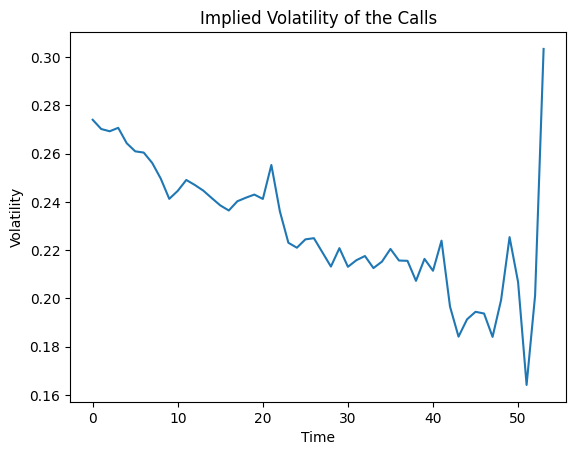

In [ ]:
df = df.reset_index(drop=True)
plt.plot(df['impl_volatility'])
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.title('Implied Volatility of the Calls')
plt.show()

In [ ]:
df['delta'].iloc[-1] = 1

<ipython-input-181-3508ae0141d0>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['delta'].iloc[-1] = 1
<ipython-input-181-3508ae0141d0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See th

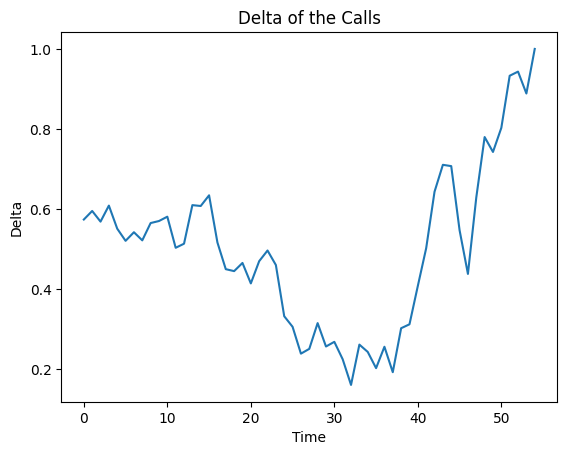

In [ ]:
plt.plot(df['delta'])
plt.xlabel('Time')
plt.ylabel('Delta')
plt.title('Delta of the Calls')
plt.show()

In [ ]:

def run_simulation_real_data(frequency, times, S, option_data, dynamic = False):
  hedge_positions = np.zeros(times)
  option_prices = np.zeros(times)
  portfolio_value = np.zeros(times)

  hedged_shares = 0   # Initially, no stock is shorted
  cash = 0            # No initial cash for simplicity

  for t in range(times):
    option_prices[t] = option_data.iloc[t]['best_bid']

    # Hedge based on the frequency
    if t % frequency == 0:
      if(not dynamic or df['gamma'].iloc[t-1] > df['gamma'].iloc[t]):

        delta = option_data.iloc[t]['delta']
        total_delta = delta

        hedge_adjustement = total_delta - hedged_shares
        hedged_shares = total_delta
        prev_cash = cash
        cash += ((0 if t == 0 else -hedge_positions[t-1]) + hedged_shares) * S.iloc[t]
        if(prev_cash < cash):
          cash -= cash * 0.01


    hedge_positions[t] = hedged_shares
    portfolio_value[t] = -(hedged_shares * S.iloc[t]) + option_prices[t] + cash
  print(hedged_shares)
  print(option_prices[0])
  print(hedge_positions[0])
  return hedge_positions, option_prices, portfolio_value, cash

1.0
109.5
0.573488
0.802709
109.5
0.573488
0.802709
109.5
0.573488
0.573488
109.5
0.573488


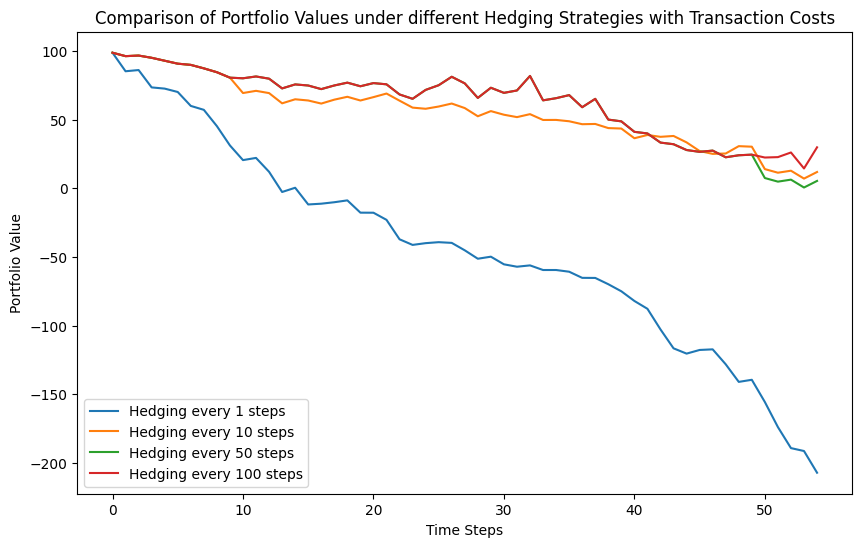

Hedging every 1 steps: Final P&L = -305.94
Hedging every 10 steps: Final P&L = -86.89
Hedging every 50 steps: Final P&L = -93.39
Hedging every 100 steps: Final P&L = -68.91


In [ ]:
# Delta Hedging approach
import matplotlib.pyplot as plt
hedge_freq = [1, 10, 50, 100]
hedge_results = {}
pnl_results = {}


for freq in hedge_freq:
  hedge_positions, option_prices, portfolio_values, cash = run_simulation_real_data(freq, len(df),
                              historical_data, df)
  hedge_results[f'Hedging every {freq} steps'] = portfolio_values
  pnl_results[f'Hedging every {freq} steps'] = portfolio_values[-1] - portfolio_values[0]
  # pnl_results[f'Hedging every {freq} steps'] = cash

# hedge_positions, option_prices, portfolio_values, cash = run_simulation_real_data(1, len(df),
#                             historical_data, df, dynamic=True)
# hedge_results[f'Hedging every dynamic steps'] = portfolio_values
# pnl_results[f'Hedging every dynamic steps'] = portfolio_values[-1] - portfolio_values[0]
# hedge_freq.append('dynamic')
# Step 6: Plot Results

plt.figure(figsize=(10, 6))
for freq in hedge_freq:
    plt.plot(hedge_results[f'Hedging every {freq} steps'], label=f'Hedging every {freq} steps')
plt.legend()
plt.title('Comparison of Portfolio Values under different Hedging Strategies with Transaction Costs')
plt.xlabel('Time Steps')
plt.ylabel('Portfolio Value')
plt.show()

# Print P&L for each strategy
for strategy, pnl in pnl_results.items():
    print(f'{strategy}: Final P&L = {pnl:.2f}')



In [ ]:
df['delta'].iloc[-1] = 1
print(df['delta'])

0     0.573488
1     0.594913
2     0.568274
3     0.608327
4     0.550679
5     0.520243
6     0.541751
7     0.521450
8     0.564694
9     0.569778
10    0.580637
11    0.502863
12    0.513073
13    0.609520
14    0.607351
15    0.634077
16    0.516113
17    0.449435
18    0.444520
19    0.464972
20    0.413820
21    0.469388
22    0.496077
23    0.459774
24    0.331741
25    0.305366
26    0.238214
27    0.250184
28    0.314586
29    0.256101
30    0.267756
31    0.224216
32    0.160053
33    0.260826
34    0.242588
35    0.202014
36    0.255446
37    0.191879
38    0.301796
39    0.311589
40    0.407500
41    0.501863
42    0.643031
43    0.710297
44    0.707026
45    0.546798
46    0.437562
47    0.628575
48    0.779681
49    0.742462
50    0.802709
51    0.932918
52    0.943265
53    0.888558
54    1.000000
Name: delta, dtype: float64


<ipython-input-171-275a6d9a6858>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['delta'].iloc[-1] = 1
<ipython-input-171-275a6d9a6858>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See th